# USANDO O ViTPose++ EM VÍDEOS

Pipeline:
1. Detector de pessoas (RT-DETR treinado em COCO + Objects365)
2. Estimador de pose top-down ViTPose++ (`usyd-community/vitpose-plus-base`)
3. Processamento frame a frame e exportação do vídeo anotado

In [ ]:
!pip install -U transformers torch torchvision opencv-python pillow tqdm

In [1]:
import torch
from transformers import (
    AutoProcessor,
    RTDetrForObjectDetection,
    VitPoseForPoseEstimation,
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print('Device:', DEVICE)

# Detector de pessoas
person_processor = AutoProcessor.from_pretrained('PekingU/rtdetr_r50vd_coco_o365')
person_model = RTDetrForObjectDetection.from_pretrained('PekingU/rtdetr_r50vd_coco_o365').to(DEVICE).eval()

# Estimador de pose ViTPose++
pose_processor = AutoProcessor.from_pretrained('usyd-community/vitpose-plus-base')
pose_model = VitPoseForPoseEstimation.from_pretrained('usyd-community/vitpose-plus-base').to(DEVICE).eval()

Device: cuda


preprocessor_config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/502M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/355 [00:00<?, ?it/s]

In [2]:
import numpy as np
import cv2
from PIL import Image

@torch.no_grad()
def detect_persons(pil_image, threshold=0.3):
    inputs = person_processor(images=pil_image, return_tensors='pt').to(DEVICE)
    outputs = person_model(**inputs)
    target_sizes = torch.tensor([(pil_image.height, pil_image.width)])
    results = person_processor.post_process_object_detection(
        outputs, target_sizes=target_sizes, threshold=threshold
    )[0]

    # Mantém apenas a classe 'person' (label 0 no COCO)
    person_boxes = []
    for label, box in zip(results['labels'], results['boxes']):
        if label.item() == 0:
            x1, y1, x2, y2 = box.tolist()
            person_boxes.append([x1, y1, x2 - x1, y2 - y1])  # XYWH
    return np.array(person_boxes, dtype=np.float32)

@torch.no_grad()
def estimate_poses(pil_image, person_boxes):
    if len(person_boxes) == 0:
        return []
    inputs = pose_processor(pil_image, boxes=[person_boxes], return_tensors='pt').to(DEVICE)

    # ViTPose++ usa Mixture-of-Experts; dataset_index=0 -> COCO (17 keypoints)
    dataset_index = torch.tensor([0] * len(person_boxes), device=DEVICE)
    outputs = pose_model(**inputs, dataset_index=dataset_index)

    pose_results = pose_processor.post_process_pose_estimation(
        outputs, boxes=[person_boxes]
    )[0]
    return pose_results

In [3]:
# Esqueleto COCO (17 keypoints)
SKELETON = [
    (5, 7), (7, 9), (6, 8), (8, 10),        # bracos
    (11, 13), (13, 15), (12, 14), (14, 16), # pernas
    (5, 6), (11, 12), (5, 11), (6, 12),     # tronco
    (0, 1), (0, 2), (1, 3), (2, 4),         # rosto
]

def draw_pose(frame, pose_results, kpt_threshold=0.3):
    for result in pose_results:
        keypoints = result['keypoints'].cpu().numpy()
        scores = result['scores'].cpu().numpy()

        # Conexões do esqueleto
        for i, j in SKELETON:
            if scores[i] > kpt_threshold and scores[j] > kpt_threshold:
                pt1 = tuple(map(int, keypoints[i]))
                pt2 = tuple(map(int, keypoints[j]))
                cv2.line(frame, pt1, pt2, (255, 0, 0), 2)

        # Pontos
        for (x, y), s in zip(keypoints, scores):
            if s > kpt_threshold:
                cv2.circle(frame, (int(x), int(y)), 4, (0, 255, 0), -1)
    return frame

In [4]:
from tqdm import tqdm

INPUT_VIDEO = 'video.mp4'
OUTPUT_VIDEO = 'video_output.mp4'

cap = cv2.VideoCapture(INPUT_VIDEO)
if not cap.isOpened():
    raise FileNotFoundError(f'Não foi possível abrir {INPUT_VIDEO}')

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (w, h))

for _ in tqdm(range(total), desc='Processando frames'):
    ret, frame = cap.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(rgb)

    boxes = detect_persons(pil_image, threshold=0.3)
    poses = estimate_poses(pil_image, boxes)

    # Caixas das pessoas
    for x, y, bw, bh in boxes:
        cv2.rectangle(frame, (int(x), int(y)), (int(x + bw), int(y + bh)), (0, 255, 255), 2)

    frame = draw_pose(frame, poses, kpt_threshold=0.3)
    writer.write(frame)

cap.release()
writer.release()
print(f'Vídeo salvo em {OUTPUT_VIDEO}')

Processando frames: 100%|██████████| 310/310 [01:59<00:00,  2.60it/s]


Vídeo salvo em video_output.mp4


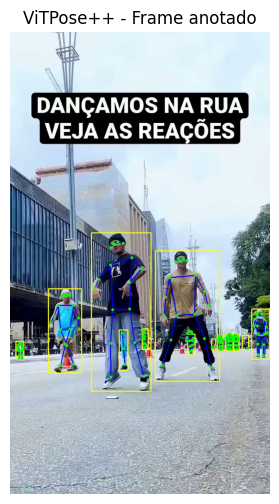

In [5]:
# Visualização rápida do primeiro frame anotado
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(OUTPUT_VIDEO)
ret, frame = cap.read()
cap.release()

if ret:
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title('ViTPose++ - Frame anotado')
    plt.axis('off')
    plt.show()